# Adult Income - Exploratory Data Analysis

This notebook performs exploratory data analysis on the cleaned dataset. It investigates the distributions of numerical and categorical features, identifies outliers, and analyzes feature correlations with the income target variable to uncover underlying patterns.

## Contents
1. Load Data
2. Check Data Info
3. Target Column Mapping
4. EDA for Numerical Data
5. EDA for Categorical Data

In [23]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
sns.set_theme(style='darkgrid')

# 1. Load Data

In [25]:
df = pd.read_csv('../data/cleaned_adult_income.csv')

# 2. Check Data Info.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29096 entries, 0 to 29095
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             29096 non-null  int64 
 1   workclass       29096 non-null  object
 2   education.num   29096 non-null  int64 
 3   marital.status  29096 non-null  object
 4   occupation      29096 non-null  object
 5   relationship    29096 non-null  object
 6   race            29096 non-null  object
 7   sex             29096 non-null  object
 8   capital.gain    29096 non-null  int64 
 9   capital.loss    29096 non-null  int64 
 10  hours.per.week  29096 non-null  int64 
 11  native.country  29096 non-null  object
 12  income          29096 non-null  object
dtypes: int64(5), object(8)
memory usage: 2.9+ MB


Find if there any duplicates or nan values

In [27]:
print(f'''
Duplicates:     {df.duplicated().sum()}
Missing Values: {df.isnull().sum().sum()}
''')


Duplicates:     0
Missing Values: 0



Categorize column types

In [28]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f'''
Numerical Columns: {len(numerical_cols)}
{numerical_cols}

Categorical Columns: {len(categorical_cols)}
{categorical_cols}
''')


Numerical Columns: 5
['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Categorical Columns: 8
['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']



# 4. EDA for `Numerical Data`

### General Exploration

In [29]:
df.describe()

,age,education.num,capital.gain,capital.loss,hours.per.week
count,29096.000000,29096.000000,29096.000000,29096.000000,29096.000000
mean,39.251340,10.102695,1197.802206,97.175179,40.637820
std,13.687157,2.645194,7778.225220,424.008232,12.735418
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,38.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


- `Age`: The average age is around 39 years, with most people between 28 and 48 years old. The dataset includes people from 17 to 90 years old.

- `Education`: The average education.num is about 10 years (High School grad), while the median is 10. Most values fall between 9 and 13.

- `Capital Gain`: The average capital gain is around $1,198 and maximum $99,999, but the median is $0. This means most people have no capital gain, while a small number of people have very large gains.

- `Capital Loss`: Similar to capital gain, the median capital loss is $0, meaning most people have no recorded capital loss. However, a few individuals have relatively large losses.

- `Hours per Week`: People work an average of around 40.6 hours per week, and the median is 40 hours. Most people work between 40 and 45 hours per week.

- `Data Distribution`: capital.gain and capital.loss are highly skewed, because most observations are zero while a small number have large values.

Check Outliers

In [30]:
outlier_rows = []

for col in ["age", "hours.per.week", "capital.gain", "capital.loss"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append([col, q1, q3, lower, upper, count, count/len(df)*100])

outlier_report = pd.DataFrame(
    outlier_rows,
    columns=["feature", "Q1", "Q3", "IQR_lower", "IQR_upper",
             "outlier_count", "outlier_%"]
)
display(outlier_report.sort_values("outlier_%", ascending=False))

,feature,Q1,Q3,IQR_lower,IQR_upper,outlier_count,outlier_%
1,hours.per.week,40.0,45.0,32.5,52.5,8476,29.131152
2,capital.gain,0.0,0.0,0.0,0.0,2698,9.272752
3,capital.loss,0.0,0.0,0.0,0.0,1511,5.193154
0,age,28.0,48.0,-2.0,78.0,141,0.484603


Check the correlation between numeric features and the target

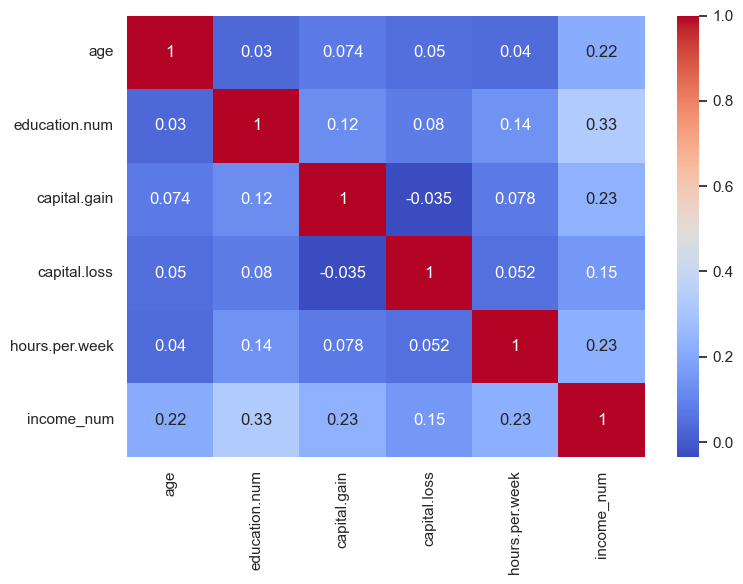

income_num        1.000000
education.num     0.332210
capital.gain      0.230696
hours.per.week    0.226323
age               0.215270
capital.loss      0.153277
Name: income_num, dtype: float64

In [31]:
df['income_num'] = df['income'].map({'<=50K': 0, '>50K': 1})

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()

display(corr_matrix['income_num'].sort_values(ascending=False))

### Age

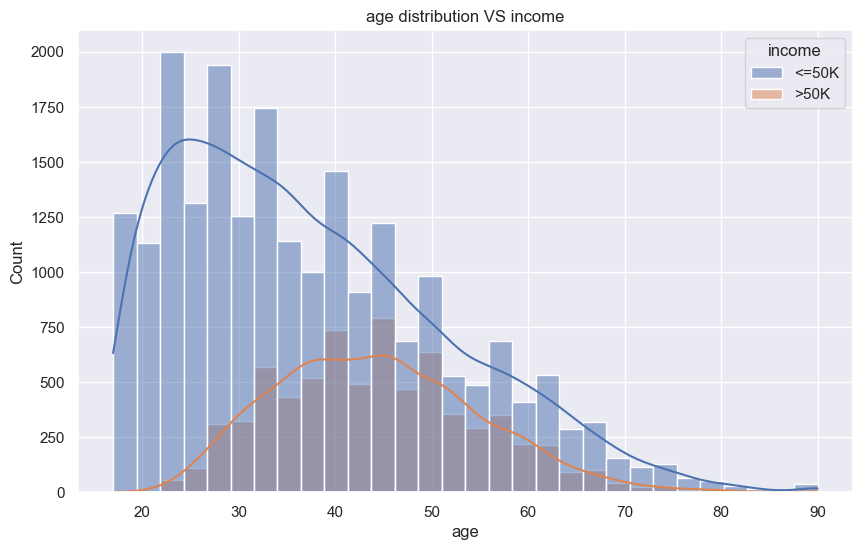

In [32]:
plt.figure(figsize=(10,6))
sns.histplot(data = df , x="age" , hue= "income" , kde=True , bins=30)
plt.title("age distribution VS income")
plt.show()

- Under $50K: Most people making this amount are in their early 20s.

- Over $50K: Most people making this amount are between 35 and 50 years old.

- People start out with a large salary gap, but this gap begins to decrease over time and with age.

### Working Hours per Week

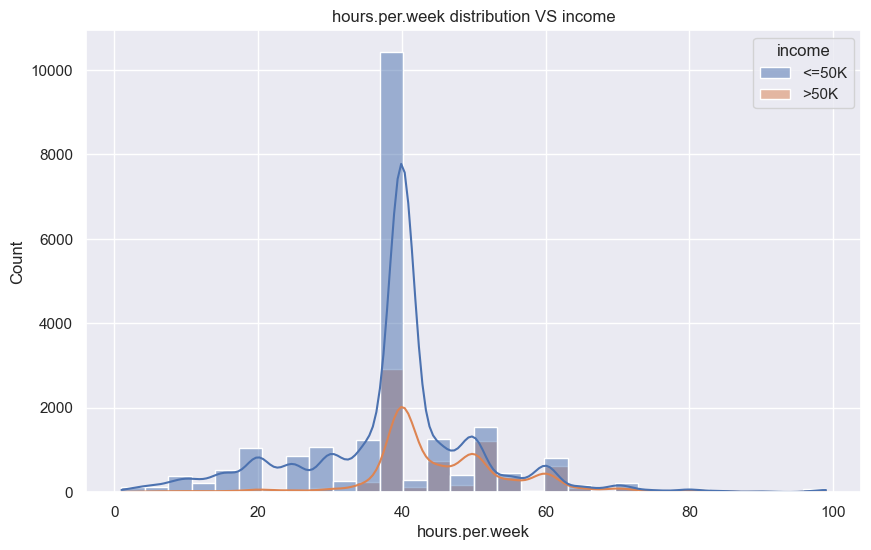

In [33]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="hours.per.week", hue="income", kde=True, bins=30)
plt.title("hours.per.week distribution VS income")
plt.show()

Working 40 hours per week (8 hours per day) is a significant factor in salary; most people who work more than 40 hours per week earn higher salaries.

### Capital Loss & Capital Gain

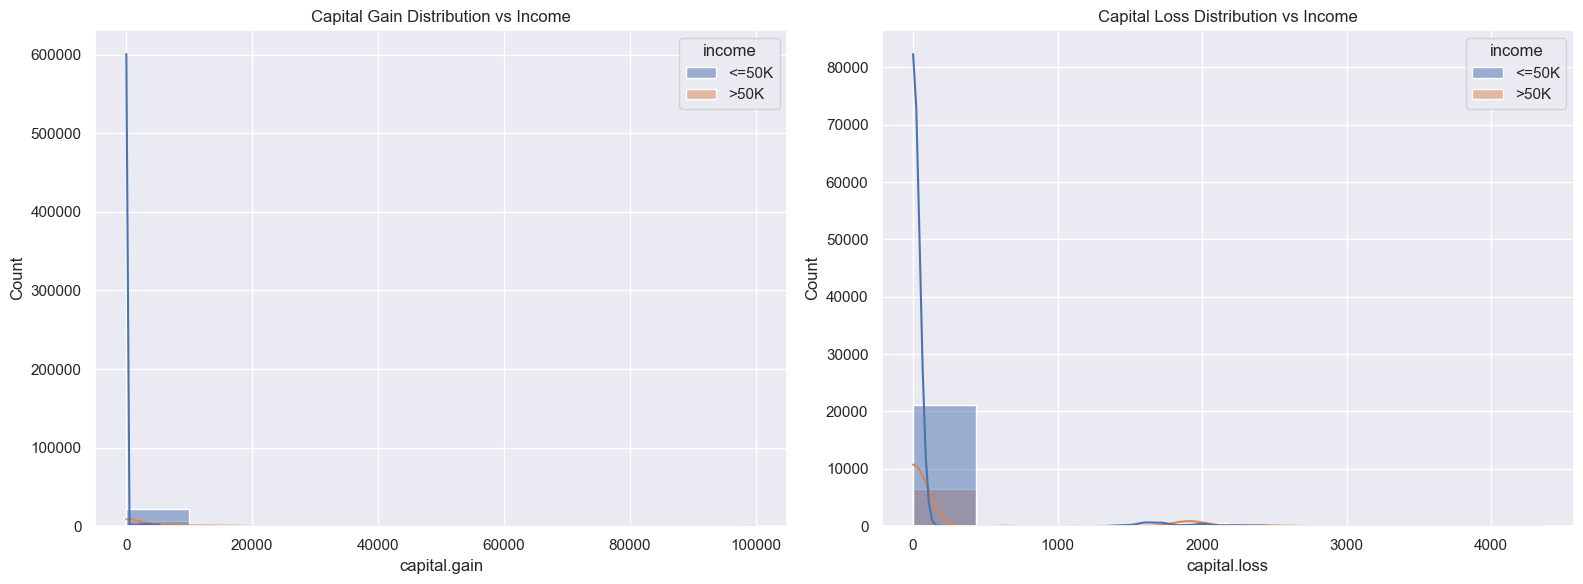

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Capital Gain
sns.histplot(data=df, x="capital.gain", hue="income", kde=True, bins=10, ax=axes[0])
axes[0].set_title("Capital Gain Distribution vs Income")

# Right plot: Capital Loss
sns.histplot(data=df, x="capital.loss", hue="income", kde=True, bins=10, ax=axes[1])
axes[1].set_title("Capital Loss Distribution vs Income")

plt.tight_layout()
plt.show()

Most people neither gained nor lost through their capital.

# 5. EDA for `Categorical Data`

### Target distribution

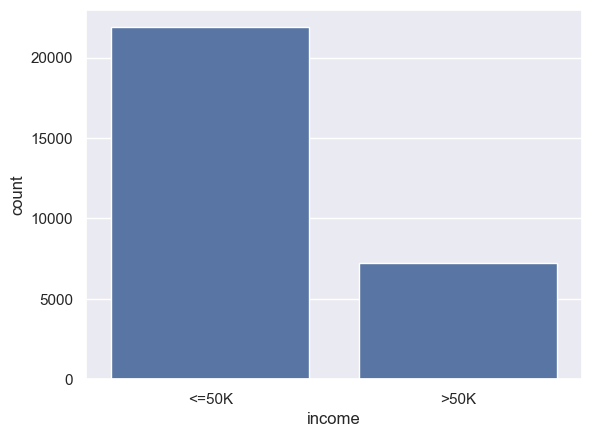

income
<=50K    75.219962
>50K     24.780038
Name: proportion, dtype: float64

In [35]:
sns.countplot(data=df, x='income')
plt.show()
display(df["income"].value_counts(normalize=True).mul(100))

There are about three times as many people in the lower income group compared to the higher one.

### Sex VS Income

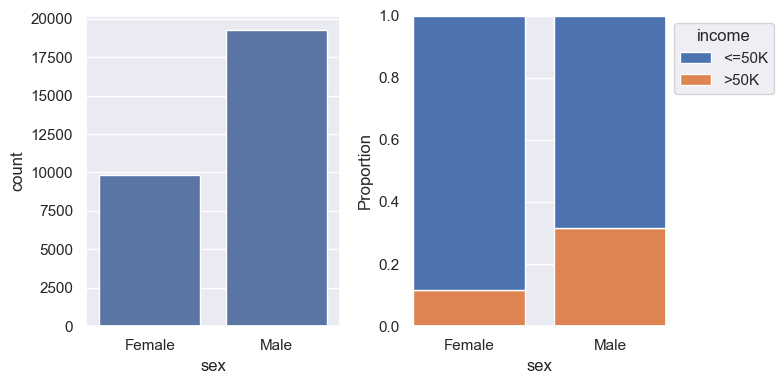

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.countplot(data=df, x='sex', ax=axes[0])

sns.histplot(data=df, x='sex', hue='income', multiple='fill', shrink=0.8, alpha=1.0, ax=axes[1])
axes[1].set_ylabel('Proportion')

sns.move_legend(axes[1], "upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

- Sample Imbalance: The dataset is heavily skewed toward males, with approximately 19,000 men compared to fewer than 10,000 women, nearly a 2:1 ratio.

- Higher Earning Rate for Men: Around 31% of males earn more than 50K, whereas only about 11% of females cross that threshold. Men in this sample are roughly three times more likely to earn over 50K.

- Dominance of the Lower Income Tier: For both groups, the majority earn 50K or less. However, the concentration is substantially higher for women (nearly 89%) than for men (around 69%).

### Education

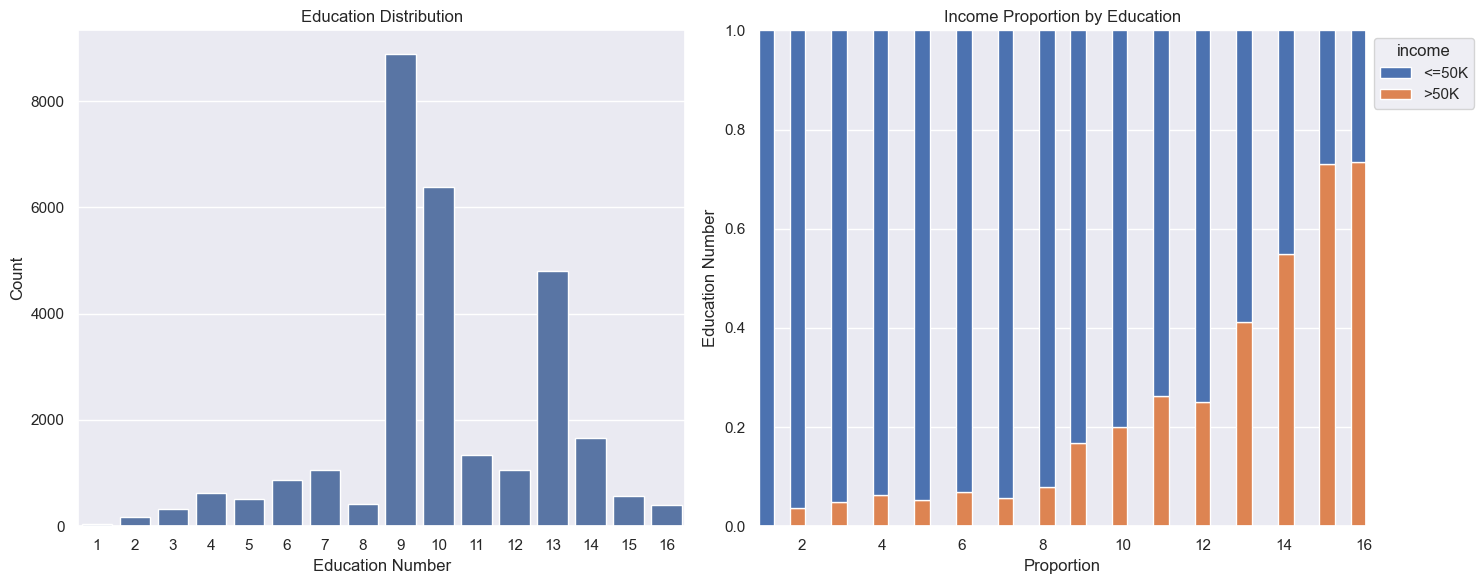

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Count of each education level
sns.countplot(data=df, x='education.num', ax=axes[0])
axes[0].set_title('Education Distribution')
axes[0].set_xlabel('Education Number')
axes[0].set_ylabel('Count')


# Income proportion within each education level
sns.histplot(data=df, x='education.num', hue='income', multiple='fill', shrink=1.5, alpha=1.0, ax=axes[1])
axes[1].set_title('Income Proportion by Education')
axes[1].set_ylabel('Education Number')
axes[1].set_xlabel('Proportion')

sns.move_legend(axes[1], "upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

Individuals with intermediate levels of education experience a wide gap in salaries, but those with advanced education generally have higher salaries.

### Countries VS Income

In [38]:
country_counts = df['native.country'].value_counts()

top_countries = country_counts.head(5)
top_countries_names = top_countries.index

df_plot = df.copy()

df_plot['country_group'] = df_plot['native.country'].where(
    df_plot['native.country'].isin(top_countries_names),
    'Other'
)

income_country = (
    df_plot.groupby(['country_group', 'income'])
           .size()
           .unstack(fill_value=0)
)

base_order = [country for country in df_plot['country_group'].value_counts().index if country != 'Other']
order = base_order + ['Other']

income_country = income_country.reindex(order)

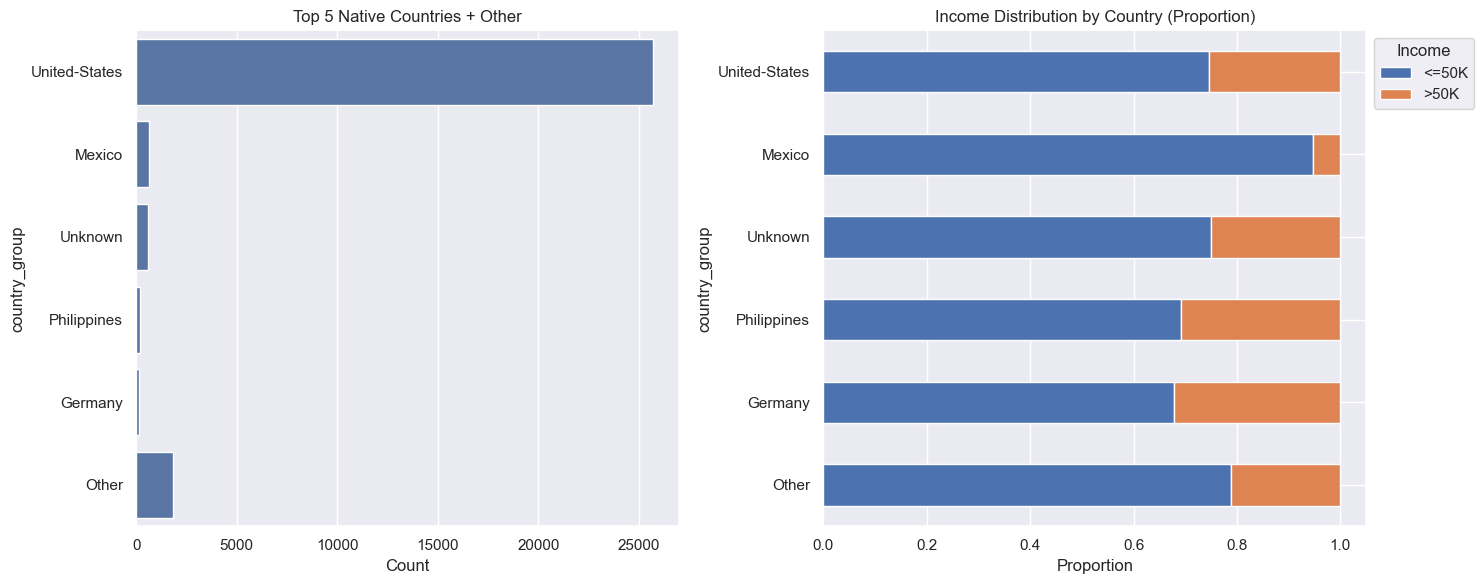

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    x=income_country.sum(axis=1).values,
    y=income_country.index,
    ax=axes[0]
)

axes[0].set_title('Top 5 Native Countries + Other')
axes[0].set_xlabel('Count')


income_country_pct = income_country.div(income_country.sum(axis=1), axis=0)

income_country_pct.plot(kind='barh', stacked=True, ax=axes[1])

axes[1].invert_yaxis()
axes[1].set_title('Income Distribution by Country (Proportion)')
axes[1].set_xlabel('Proportion')
axes[1].legend(title='Income', bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
plt.show()

- Data Skew: The sample is overwhelmingly US-based (25,000+ records), making non-US country metrics small-sample estimates.

- Top Earning Rates: Individuals from Germany and the Philippines have the highest rates of earning >50K (~32%), outperforming the US (~25%).

- Lowest Earning Rate: Mexico shows the lowest proportion of >50K earners (<10%), with over 90% earning 50K or less.

### Relationship & Marital Status VS Income

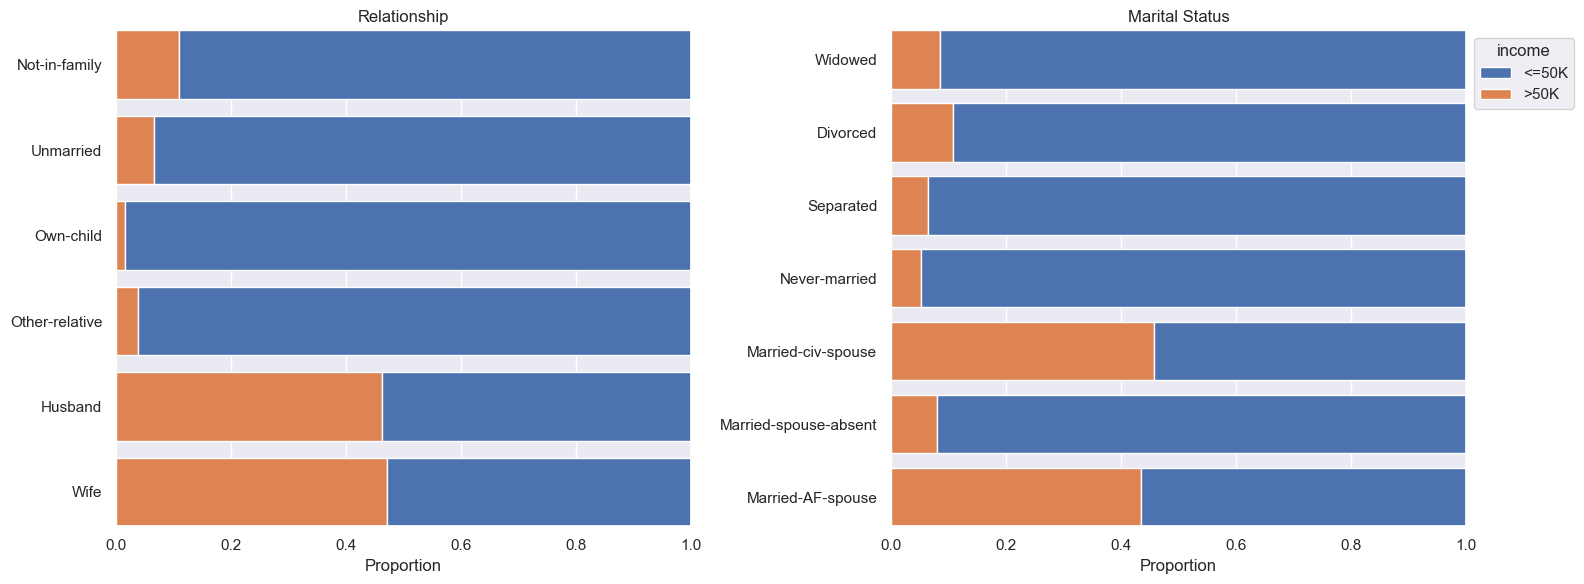

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Relationship
sns.histplot(data=df, y='relationship', hue='income', multiple='fill', shrink=0.8, alpha=1.0, ax=axes[0])
axes[0].set_title('Relationship')
axes[0].set_ylabel('')
axes[0].set_xlabel('Proportion')
axes[0].get_legend().remove()

# Right plot: Marital Status
sns.histplot(data=df, y='marital.status', hue='income', multiple='fill', shrink=0.8, alpha=1.0, ax=axes[1])
axes[1].set_title('Marital Status')
axes[1].set_ylabel('')
axes[1].set_xlabel('Proportion')
sns.move_legend(axes[1], "upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

- **Marriage Strongly Correlates with High Income:** Across both charts, married individuals have the highest chance of earning >50K. Nearly half of those classified as Husband or Wife earn over 50K (~47%), and married status groups (Married-civ-spouse and Married-AF-spouse) lead at roughly 44–46%.

- **Low High-Earner Rates for Non-Married Groups:** Non-married categories including: Never-married, Separated, Divorced, and Widowed—rarely cross the high-income threshold, with 85% to over 90% earning <=50K.

- **Lowest Earning Groups:** Individuals listed as Own-child and Other-relative have the smallest share of >50K earners (<5%), likely reflecting younger ages, or dependent family status.

### Workclass & Occupation VS Income

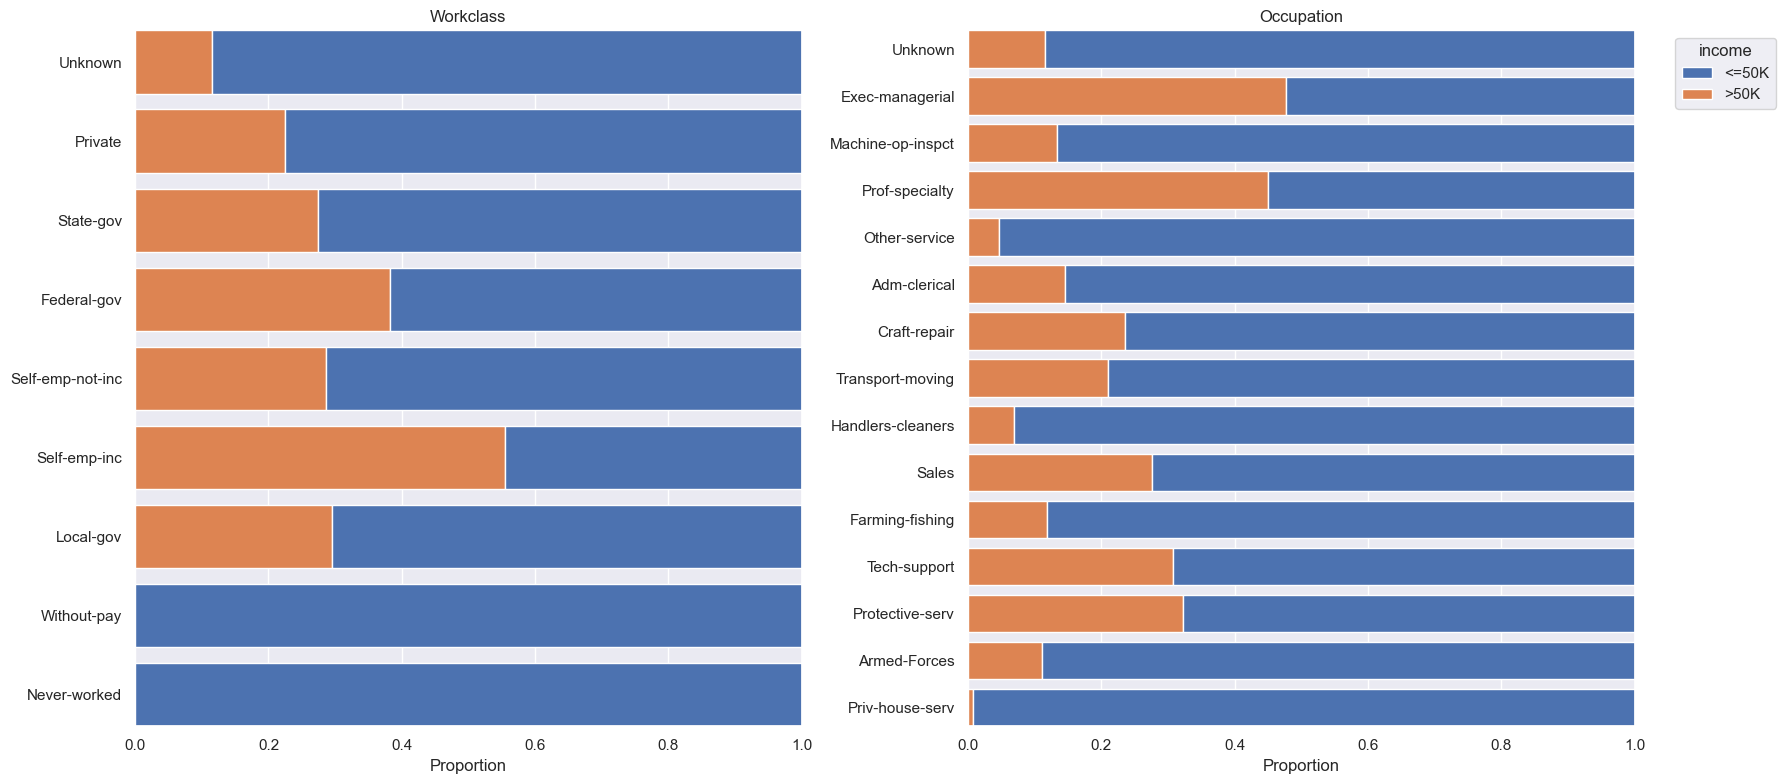

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left plot: Workclass
sns.histplot(data=df, y='workclass', hue='income', multiple='fill', shrink=0.8, alpha=1.0, ax=axes[0])
axes[0].set_title('Workclass')
axes[0].set_ylabel('')
axes[0].set_xlabel('Proportion')
axes[0].get_legend().remove()

# Right plot: Occupation
sns.histplot(data=df, y='occupation', hue='income', multiple='fill', shrink=0.8, alpha=1.0, ax=axes[1])
axes[1].set_title('Occupation')
axes[1].set_ylabel('')
axes[1].set_xlabel('Proportion')
sns.move_legend(axes[1], "upper left", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

- **Top Workclass Earners:** Self-emp-inc has the highest rate of >50K income (over 55%), followed by Federal-gov (~38%).

- **Top Occupation Earners:** White-collar roles dominate high earnings, led by Exec-managerial (~48%) and Prof-specialty (~45%).

- **Lowest Earning Groups:**

    - Workclass: Without-pay and Never-worked show virtually 0% in the >50K bracket.

    - Occupation: Priv-house-serv, Other-service, and Handlers-cleaners have the smallest share of >50K earners (<10%).

- **Baseline Distribution:** Most standard job sectors (e.g., Private, Local-gov, Sales, Craft-repair) hover between 20% and 30% for high earners.

### Race VS Income

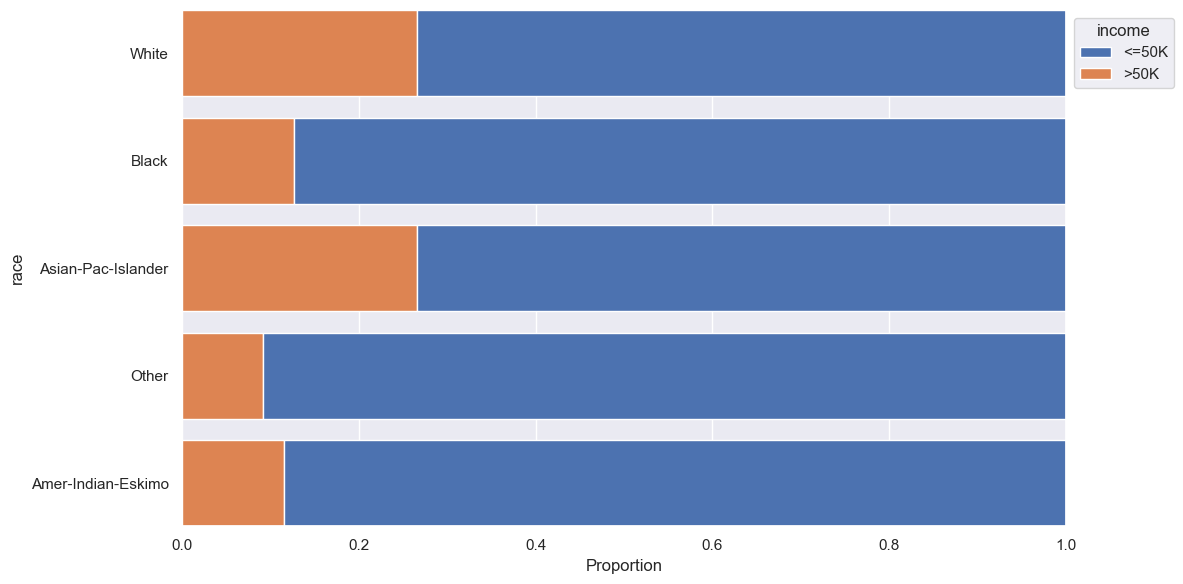

In [42]:
plt.figure(figsize=(12, 6))

ax = sns.histplot(data=df, y='race', hue='income', multiple='fill', shrink=0.8, alpha=1.0)

ax.set_xlabel('Proportion')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

- **Highest Share of High Earners:** Asian-Pac-Islander and White groups have the largest proportions earning >50K, both at roughly ~25%.

- **Lower High-Earner Rates:** The remaining groups: Black, Amer-Indian-Eskimo, and Other—show significantly lower shares of >50K earners, ranging ~10%.